# Compare climatology from World Ocean Atlas to CM2.1 and FLOR historical runs (1981-2010)

Figure S12

In [1]:
import numpy as np
import xarray as xr 
import matplotlib.pyplot as plt
import netCDF4

In [2]:
print(netCDF4.__version__)

1.7.2


In [7]:
ls /projects/GEOCLIM/LRGROUP/shared_data/woa18/temp/1deg/monthly

woa18_decav_t01_01.nc  woa18_decav_t05_01.nc  woa18_decav_t09_01.nc
woa18_decav_t02_01.nc  woa18_decav_t06_01.nc  woa18_decav_t10_01.nc
woa18_decav_t03_01.nc  woa18_decav_t07_01.nc  woa18_decav_t11_01.nc
woa18_decav_t04_01.nc  woa18_decav_t08_01.nc  woa18_decav_t12_01.nc


In [8]:
ls /projects/GEOCLIM/LRGROUP/shared_data/woa18/salt/1deg/monthly

woa18_decav_s01_01.nc  woa18_decav_s05_01.nc  woa18_decav_s09_01.nc
woa18_decav_s02_01.nc  woa18_decav_s06_01.nc  woa18_decav_s10_01.nc
woa18_decav_s03_01.nc  woa18_decav_s07_01.nc  woa18_decav_s11_01.nc
woa18_decav_s04_01.nc  woa18_decav_s08_01.nc  woa18_decav_s12_01.nc


In [3]:
# North Pacific box
lat1, lat2 = 40, 60
lon1, lon2 = -190, -140

In [4]:
import xarray as xr
import matplotlib.pyplot as plt

# Define directories and file patterns
dir_temp = '/projects/GEOCLIM/LRGROUP/shared_data/woa18/temp/1deg/monthly'
dir_salt = '/projects/GEOCLIM/LRGROUP/shared_data/woa18/salt/1deg/monthly'

file_pattern_temp = f'{dir_temp}/woa18_decav_t*_01.nc'  # Temperature files
file_pattern_salt = f'{dir_salt}/woa18_decav_s*_01.nc'  # Salinity files

# Load and merge temperature dataset
ds_temp = xr.open_mfdataset(file_pattern_temp, engine='netcdf4', decode_times=False, combine='by_coords')
T = ds_temp.t_mn

# Load and merge salinity dataset
ds_salt = xr.open_mfdataset(file_pattern_salt, engine='netcdf4', decode_times=False, combine='by_coords')
S = ds_salt.s_mn

# Compute North Pacific mean profile for temperature
NP_T = T.mean('time').sel(lon=slice(lon1, lon2), lat=slice(lat1, lat2)).mean(('lat', 'lon'))

# Compute North Pacific mean profile for salinity
NP_S = S.mean('time').sel(lon=slice(lon1, lon2), lat=slice(lat1, lat2)).mean(('lat', 'lon'))


In [5]:
# save climatology
S.to_netcdf('./processed_data/WOA_salt_clim_1deg_monthly.nc')
T.to_netcdf('./processed_data/WOA_temp_clim_1deg_monthly.nc')

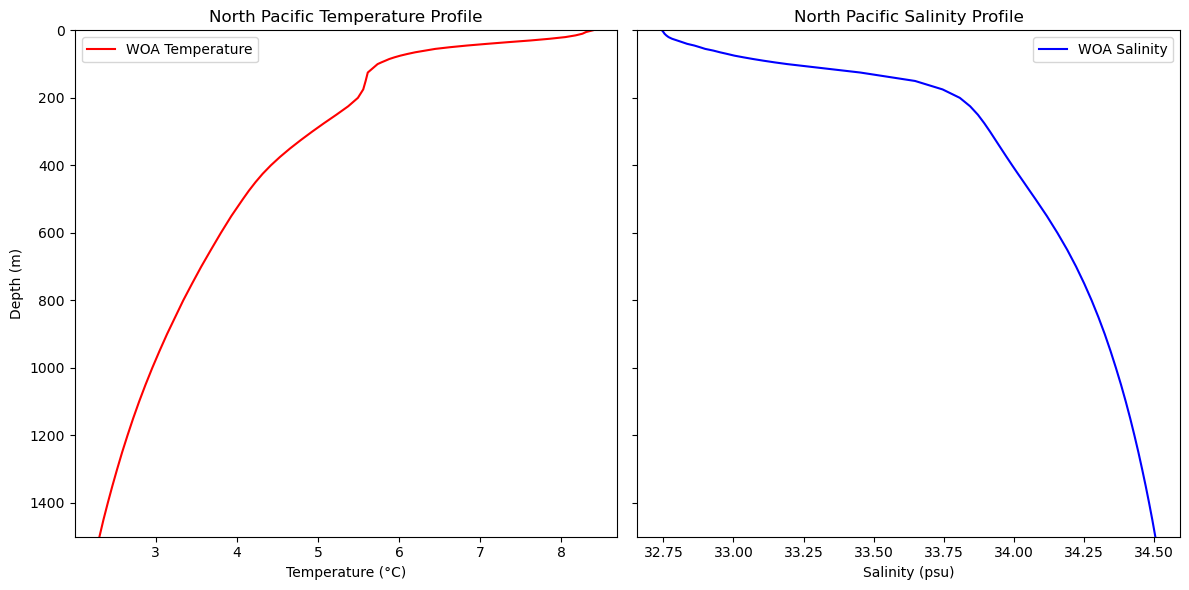

In [6]:
# Create subplots
fig, axes = plt.subplots(1, 2, figsize=(12, 6), sharey=True)

# Plot temperature on the first subplot
axes[0].plot(NP_T, NP_T.depth, label='WOA Temperature', color='r')
axes[0].set_ylim(1500, 0)  # Invert y-axis for depth
axes[0].set_xlabel('Temperature (°C)')
axes[0].set_ylabel('Depth (m)')
axes[0].set_title('North Pacific Temperature Profile')
axes[0].legend()

# Plot salinity on the second subplot
axes[1].plot(NP_S, NP_S.depth, label='WOA Salinity', color='b')
axes[1].set_ylim(1500, 0)  # Invert y-axis for depth
axes[1].set_xlabel('Salinity (psu)')
axes[1].set_title('North Pacific Salinity Profile')
axes[1].legend()

# Display the plots
plt.tight_layout()
plt.show()

### Add the data from FLOR and CM2.1 historical runs

In [8]:
def load_historical_data_NP(dir_in, filename_extension, varlist=['temp','salt','rho'], 
                            year1=1981, year2=2010, lat1=40, lat2=60, lon1=-190, lon2=-140):
    for year in np.arange(year1, year2+1, 1):
        print(year)
        ds = xr.open_dataset(f'{dir_in}/{year}0101.{filename_extension}')[varlist]

        # select north pacific only
        ds = ds.sel(yt_ocean=slice(lat1, lat2), xt_ocean=slice(lon1,lon2))#.mean(('xt_ocean','yt_ocean'))
        
        if year == year1:
            ds_all = ds
        else:
            ds_all = xr.concat([ds_all,ds], 'time')

    return ds_all

In [9]:
# load FLOR data
# ls /projects/w/wenchang/MODEL_OUT/FLOR/HistRCP45_tigercpu_intelmpi_18_576PE/en01/POSTP/*ocean.nc

dir_in = '/projects/w/wenchang/MODEL_OUT/FLOR/HistRCP45_tigercpu_intelmpi_18_576PE/en01/POSTP'
filename_extension = 'ocean.nc'
varlist = ['temp','salt','rho']

FLOR_ds_NP = load_historical_data_NP(dir_in, filename_extension, varlist, year1=1981, year2=2010)

1981
1982
1983
1984
1985
1986
1987
1988
1989
1990
1991
1992
1993
1994
1995
1996
1997
1998
1999
2000
2001
2002
2003
2004
2005
2006
2007
2008
2009
2010


In [10]:
# load CM2.1 data
# ls /projects/GEOCLIM/wenchang/MODEL_OUT/CM2.1p1/HistRCP45_tigercpu_intelmpi_18_80PE/en01/POSTP/*ocean_month*
dir_in = '/projects/GEOCLIM/wenchang/MODEL_OUT/CM2.1p1/HistRCP45_tigercpu_intelmpi_18_80PE/en01/POSTP'
filename_extension = 'ocean_month.nc'
varlist = ['temp','salt','rho']

CM21_ds_NP = load_historical_data_NP(dir_in, filename_extension, varlist, year1=1981, year2=2010)

1981
1982
1983
1984
1985
1986
1987
1988
1989
1990
1991
1992
1993
1994
1995
1996
1997
1998
1999
2000
2001
2002
2003
2004
2005
2006
2007
2008
2009
2010


In [11]:
# save data
FLOR_ds_NP.to_netcdf('./MODEL_OUT/NPacific/temp_salt_rho_FLOR_1981-2010.nc')
CM21_ds_NP.to_netcdf('./MODEL_OUT/NPacific/temp_salt_rho_CM21_1981-2010.nc')

# load data if already saved

In [7]:
FLOR_ds_NP = xr.open_dataset('./MODEL_OUT/NPacific/temp_salt_rho_FLOR_1981-2010.nc')
CM21_ds_NP = xr.open_dataset('./MODEL_OUT/NPacific/temp_salt_rho_CM21_1981-2010.nc')

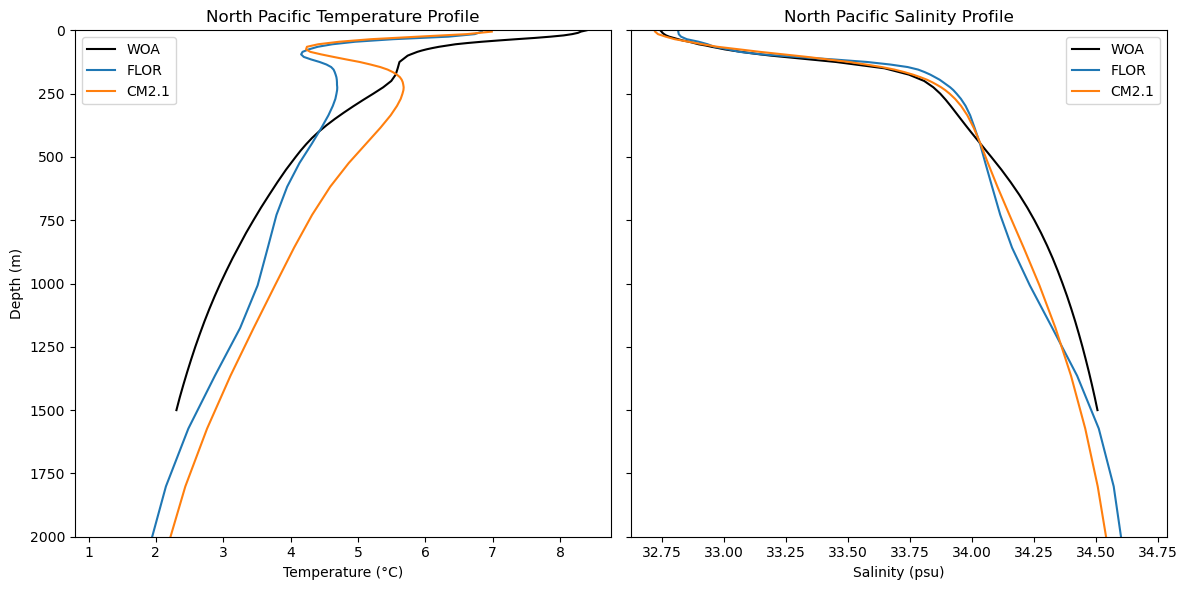

In [8]:
# Create subplots
fig, axes = plt.subplots(1, 2, figsize=(12, 6), sharey=True)

# Plot temperature on the first subplot
axes[0].plot(NP_T, NP_T.depth, label='WOA',color='k')
axes[0].plot(FLOR_ds_NP.temp.mean(('time','xt_ocean','yt_ocean')), FLOR_ds_NP.st_ocean, label='FLOR')
axes[0].plot(CM21_ds_NP.temp.mean(('time','xt_ocean','yt_ocean')), CM21_ds_NP.st_ocean, label='CM2.1')
axes[0].set_ylim(2000, 0)  # Invert y-axis for depth
axes[0].set_xlabel('Temperature (°C)')
axes[0].set_ylabel('Depth (m)')
axes[0].set_title('North Pacific Temperature Profile')
axes[0].legend()

# Plot salinity on the second subplot
axes[1].plot(NP_S, NP_S.depth, label='WOA',color='k')
axes[1].plot(FLOR_ds_NP.salt.mean(('time','xt_ocean','yt_ocean')), FLOR_ds_NP.st_ocean, label='FLOR')
axes[1].plot(CM21_ds_NP.salt.mean(('time','xt_ocean','yt_ocean')), CM21_ds_NP.st_ocean, label='CM2.1')
axes[1].set_ylim(2000, 0)  # Invert y-axis for depth
axes[1].set_xlabel('Salinity (psu)')
axes[1].set_title('North Pacific Salinity Profile')
axes[1].legend()

# Display the plots
plt.tight_layout()
plt.show()

### compute density or $N^2$

In [9]:
#FLOR_NP = FLOR_ds_CTRL.sel(xt_ocean=slice(-170, -140), yt_ocean=slice(40, 60)).mean(('time'))#.mean(('xt_ocean','yt_ocean'))

In [10]:
#CM21_NP = CM21_ds_CTRL.sel(xt_ocean=slice(-170, -140), yt_ocean=slice(40, 60)).mean(('time'))#.mean(('xt_ocean','yt_ocean'))

In [11]:
import gsw

def SP_to_SA(SP,depth,latname='yt_ocean',lonname='xt_ocean'):
    pressure = gsw.p_from_z(-depth,SP[latname]) # get sea pressure from height, lat (negative in ocean)
    SA = gsw.SA_from_SP(SP,pressure,SP[lonname],SP[latname]) 
    return SA, pressure

def SP_PT_to_SA_CT(practical_salinity, potential_temp, depth,latname='yt_ocean',lonname='xt_ocean'):
    # inputs: practical salinity (unitless/psu), potential temperature (deg C)
    SA, pressure = SP_to_SA(practical_salinity,depth,latname,lonname)
    CT = gsw.CT_from_pt(SA, potential_temp)

    return SA, CT, pressure


In [12]:
# CM2.1
SA, CT, pressure = SP_PT_to_SA_CT(CM21_ds_NP.salt,CM21_ds_NP.temp,CM21_ds_NP.st_ocean)
CM21_NP_rho = gsw.rho(SA,CT,pressure)
CM21_NP_rho = CM21_NP_rho.mean(('yt_ocean','xt_ocean'))

In [13]:
# FLOR
SA, CT, pressure = SP_PT_to_SA_CT(FLOR_ds_NP.salt,FLOR_ds_NP.temp,FLOR_ds_NP.st_ocean)
FLOR_NP_rho = gsw.rho(SA,CT,pressure)
FLOR_NP_rho = FLOR_NP_rho.mean(('yt_ocean','xt_ocean'))

In [14]:
# WOA
SA, CT, pressure = SP_PT_to_SA_CT(S,T,T.depth,latname='lat',lonname='lon')
WOA_NP_rho = gsw.rho(SA,CT,pressure)
WOA_NP_rho = WOA_NP_rho.mean(('lat','lon'))#.mean('time')

/tmp/ipykernel_562361/212216693.py:39: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


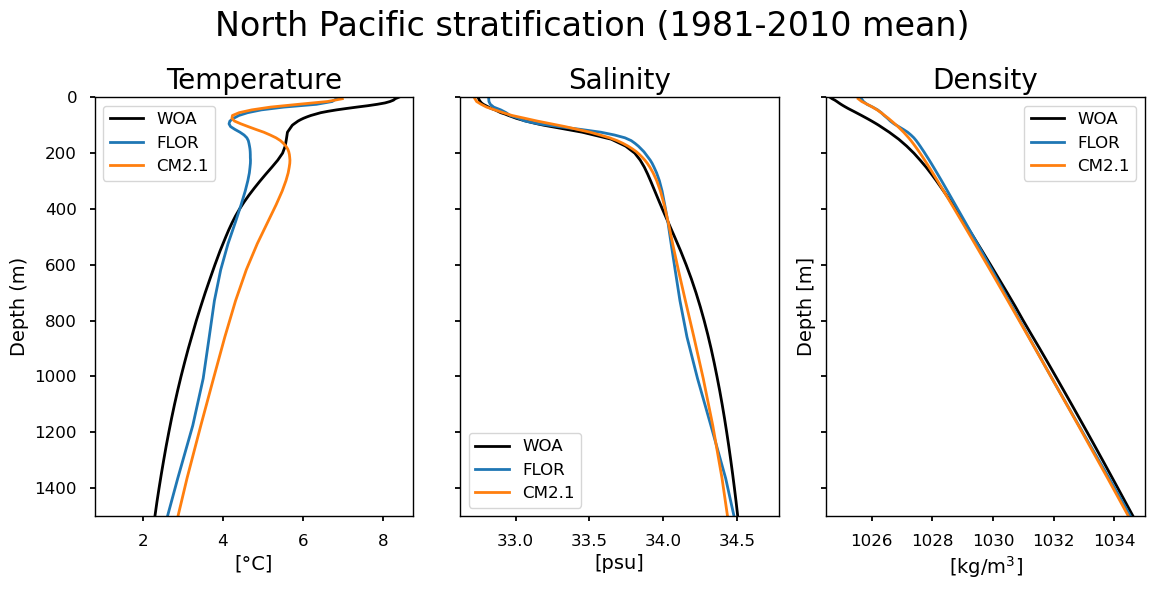

In [16]:
# Create figure

plt.style.use('../func/paper.mplstyle')

fig, axes = plt.subplots(1, 3, figsize=(12, 6), sharey=True)

# Plot temperature on the first subplot
axes[0].plot(NP_T, NP_T.depth, label='WOA',color='k')
axes[0].plot(FLOR_ds_NP.temp.mean(('time','xt_ocean','yt_ocean')), FLOR_ds_NP.st_ocean, label='FLOR')
axes[0].plot(CM21_ds_NP.temp.mean(('time','xt_ocean','yt_ocean')), CM21_ds_NP.st_ocean, label='CM2.1')
axes[0].set_ylim(1500, 0)  # Invert y-axis for depth
axes[0].set_xlabel('[°C]')
axes[0].set_ylabel('Depth (m)')
axes[0].set_title('Temperature')
axes[0].legend()

# Plot salinity on the second subplot
axes[1].plot(NP_S, NP_S.depth, label='WOA',color='k')
axes[1].plot(FLOR_ds_NP.salt.mean(('time','xt_ocean','yt_ocean')), FLOR_ds_NP.st_ocean, label='FLOR')
axes[1].plot(CM21_ds_NP.salt.mean(('time','xt_ocean','yt_ocean')), CM21_ds_NP.st_ocean, label='CM2.1')
axes[1].set_ylim(1500, 0)  # Invert y-axis for depth
axes[1].set_xlabel('[psu]')
axes[1].set_title('Salinity')
axes[1].legend()

axes[2].plot(WOA_NP_rho.mean('time'), NP_T.depth, label='WOA',color='k')
axes[2].plot(FLOR_NP_rho.mean('time'), FLOR_ds_NP.st_ocean, label='FLOR')
axes[2].plot(CM21_NP_rho.mean('time'), CM21_ds_NP.st_ocean, label='CM2.1')
axes[2].set_ylim(1500, 0)  # Invert y-axis for depth
axes[2].set_xlabel('[kg/m$^3$]')
axes[2].set_ylabel('Depth [m]')
axes[2].set_title('Density')
axes[2].legend()
axes[2].set_xlim(1024.5,1035)

fig.suptitle('North Pacific stratification (1981-2010 mean)')

# Display the plots
plt.tight_layout()

plt.savefig('FigureS12.pdf')
plt.show()